# Notebook 06 – BiLSTM Autoencoder for Stress Pattern Extraction

**Objective:** Learn the compressed 32-dimensional stress embeddings from 6-month temporal payment behavior sequences using a Bidirectional LSTM autoencoder.

**Input:** `data/processed/sbdr_final_dataset.csv` (Phase 1 output)  
**Output:** `data/processed/06_with_stress_vectors.csv` with 32 stress dimensions + anomaly flags

---

## Architectural Decisions

**Branch 2 scope — temporal sequences only:**  
The BiLSTM processes only UCI-derived temporal features (payment status, bill amounts, payment amounts, utilization ratios, pay ratios). Sparkov aggregate features (`sp_avg_monthly_spend`, `sp_spend_volatility`, `spend_to_limit`, `sp_fraud_x_delinq`) are **not** included here — they are static per-customer summaries with no time-axis, so feeding them as repeated timestep values would be architecturally dishonest. They feed XGBoost directly as static tabular features in Notebook 07.

**Unsupervised by design:**  
The autoencoder is trained without label supervision. Branch 2's role is to discover hidden behavioral patterns in payment sequences independently. Supervision (recovery tier classification) happens downstream in XGBoost (Branch 3). Injecting `distress_encoded` into the bottleneck would leak label signal into the embedding and undermine the 'hidden stress detection' claim.

**Reconstruction error as Life Event signal:**  
The autoencoder's per-customer reconstruction error serves as the 'Life Event anomaly' signal from the roadmap (Objective 1). Unusual temporal patterns — sudden payment stop, rapid delinquency escalation — reconstruct poorly and score high. `bilstm_anomaly_flag` is the operational implementation of this.

---

## Known Issues (Minor — deferred to integration pass)

- **Sequence direction:** Columns ordered most-recent → oldest (BILL_AMT1=most recent). Standard convention is oldest → newest, but BiLSTM processes both directions so results are unaffected.
- **Anomaly threshold on full dataset:** The 95th-percentile threshold is computed across all 30K customers. Stricter setup would compute it on a held-out test split only. Acceptable for capstone scope.
- **No held-out test set:** 80/20 train/val split only. Sufficient for autoencoder convergence monitoring; rigorous generalization testing deferred to final evaluation pass.

---

In [15]:
# Cell 1: Imports
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
from pathlib import Path
import json
import warnings
warnings.filterwarnings('ignore')

# Validation imports (Cell 10b: distress tier validation)
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from scipy import stats

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.backends.mps.is_available():
    print("MPS (Apple Silicon) available")


PyTorch version: 2.10.0+cu128
CUDA available: False


In [16]:
# Cell 2: Configuration

CONFIG = {
    # ----- File Paths -----
    'input_path': '../../../data/processed/sbdr_final_dataset.csv',
    'output_path': '../../../data/processed/06_with_stress_vectors.csv',
    'model_dir': '../../../models/bilstm',
    'manifest_path': '../../../models/bilstm/bilstm_manifest.json',

    # ----- Column Names (from Phase 1 CSV) -----
    # Payment status: 6 months (NOTE: UCI uses PAY_0, PAY_2-6, no PAY_1)
    'pay_status_cols': ['PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6'],

    # Bill amounts: 6 months (BILL_AMT1 = most recent)
    'bill_amt_cols': ['BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6'],

    # Payment amounts: 6 months (PAY_AMT1 = most recent)
    'pay_amt_cols': ['PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6'],

    # Utilization ratios: 6 months (from Phase 1 feature engineering)
    'util_ratio_cols': ['util_ratio_1', 'util_ratio_2', 'util_ratio_3', 'util_ratio_4', 'util_ratio_5', 'util_ratio_6'],

    # Pay ratios: 6 months (from Phase 1 feature engineering)
    'pay_ratio_cols': ['pay_ratio_1', 'pay_ratio_2', 'pay_ratio_3', 'pay_ratio_4', 'pay_ratio_5', 'pay_ratio_6'],

    # Target column
    'target_col': 'default payment next month',

    # ----- Model Architecture -----
    'seq_len': 6,           # 6 months of history
    'n_features': 5,        # Features per timestep: pay_status, bill_amt, pay_amt, util_ratio, pay_ratio
    'hidden_size': 64,      # LSTM hidden dimension
    'num_layers': 2,        # LSTM layers
    'embed_dim': 32,        # Bottleneck / stress vector dimension
    'dropout': 0.2,

    # ----- Training -----
    'batch_size': 256,
    'epochs': 100,
    'lr': 1e-3,
    'patience': 10,         # Early stopping patience
    'grad_clip': 1.0,

    # ----- Anomaly Detection -----
    'anomaly_percentile': 95,  # Reconstruction error threshold percentile

    # ----- Random Seed -----
    'seed': 42
}

# Set seeds for reproducibility
np.random.seed(CONFIG['seed'])
torch.manual_seed(CONFIG['seed'])
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(CONFIG['seed'])

# Device selection
if torch.cuda.is_available():
    DEVICE = torch.device('cuda')
elif torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
else:
    DEVICE = torch.device('cpu')
print(f"Using device: {DEVICE}")

# Create model directory
Path(CONFIG['model_dir']).mkdir(parents=True, exist_ok=True)
print("Configuration loaded.")

Using device: cpu
Configuration loaded.


In [17]:
# Cell 3: Load Data and Build Sequences

def build_sequences(df, config, train_idx=None):
    """
    Build 3D tensor of shape (N, seq_len, n_features) from wide DataFrame.
    Normalization statistics are computed on train_idx rows only (if provided)
    to prevent data leakage into the validation set.

    Features per timestep:
    - Payment status: MinMax scaled to [-1, 1] using UCI fixed range [-2, 8]
    - Bill amount:    log1p transform, standardized on train stats only
    - Payment amount: log1p transform, standardized on train stats only
    - Utilization ratio: clipped to [0, 2], centered to [-1, 1]
    - Pay ratio:      clipped, log1p transform, standardized on train stats only
    """
    n_samples = len(df)
    seq_len   = config['seq_len']
    n_features = config['n_features']

    # Initialize output tensor
    sequences = np.zeros((n_samples, seq_len, n_features), dtype=np.float32)

    # Which rows to use for computing normalization stats (train only, no leakage)
    stat_idx = train_idx if train_idx is not None else np.arange(n_samples)

    # Feature 0: Payment status — MinMax to [-1, 1] using known UCI range [-2, 8]
    # Semantic values: -2=paid in advance, -1=paid on time, 0=min paid, 1-8=months late
    PAY_MIN, PAY_MAX = -2.0, 8.0
    pay_status = df[config['pay_status_cols']].values.astype(np.float32)
    sequences[:, :, 0] = (pay_status - PAY_MIN) / (PAY_MAX - PAY_MIN) * 2 - 1
    # Result: -2 → -1.0, -1 → -0.8, 0 → -0.6, 8 → +1.0  (true [-1, 1] range)

    # Feature 1: Bill amounts — log1p, then standardize on train stats
    bill_amt = np.clip(df[config['bill_amt_cols']].values.astype(np.float32), 0, None)
    bill_amt_log = np.log1p(bill_amt)
    bill_mean = bill_amt_log[stat_idx].mean()
    bill_std  = bill_amt_log[stat_idx].std() + 1e-8
    sequences[:, :, 1] = (bill_amt_log - bill_mean) / bill_std

    # Feature 2: Payment amounts — log1p, then standardize on train stats
    pay_amt = np.clip(df[config['pay_amt_cols']].values.astype(np.float32), 0, None)
    pay_amt_log = np.log1p(pay_amt)
    pay_mean = pay_amt_log[stat_idx].mean()
    pay_std  = pay_amt_log[stat_idx].std() + 1e-8
    sequences[:, :, 2] = (pay_amt_log - pay_mean) / pay_std

    # Feature 3: Utilization ratio — clip to [0, 2], map [0,1] → [-1,1]
    util_ratio = np.clip(df[config['util_ratio_cols']].values.astype(np.float32), 0, 2)
    sequences[:, :, 3] = (util_ratio - 0.5) * 2

    # Feature 4: Pay ratio — clip, log1p, standardize on train stats
    pay_ratio = np.clip(df[config['pay_ratio_cols']].values.astype(np.float32), 0, 5)
    pay_ratio_log = np.log1p(pay_ratio)
    pr_mean = pay_ratio_log[stat_idx].mean()
    pr_std  = pay_ratio_log[stat_idx].std() + 1e-8
    sequences[:, :, 4] = (pay_ratio_log - pr_mean) / pr_std

    # Store normalization params — needed for inference on new customers
    norm_params = {
        'pay_status_min': float(PAY_MIN), 'pay_status_max': float(PAY_MAX),
        'bill_mean': float(bill_mean), 'bill_std': float(bill_std),
        'pay_mean': float(pay_mean),   'pay_std': float(pay_std),
        'pay_ratio_mean': float(pr_mean), 'pay_ratio_std': float(pr_std)
    }

    return sequences, norm_params


# Load data
print('Loading data...')
df = pd.read_csv(CONFIG['input_path'])
print(f'Loaded {len(df):,} rows, {len(df.columns)} columns')

# Verify required columns exist
required_cols = (CONFIG['pay_status_cols'] + CONFIG['bill_amt_cols'] +
                 CONFIG['pay_amt_cols'] + CONFIG['util_ratio_cols'] +
                 CONFIG['pay_ratio_cols'])
missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise ValueError(f'Missing columns: {missing}')
print(f'All {len(required_cols)} required temporal columns found')

# Generate train/val split indices BEFORE building sequences
# Critical: normalization stats must be computed on training data only (prevents leakage)
n_total  = len(df)
n_train  = int(0.8 * n_total)
all_indices  = np.random.permutation(n_total)
train_idx_np = all_indices[:n_train]
val_idx_np   = all_indices[n_train:]
print(f'\nSplit: {n_train:,} train / {len(val_idx_np):,} val (indices generated before normalization)')

# Build sequences — normalization stats computed on train rows only
print('Building sequences...')
sequences, norm_params = build_sequences(df, CONFIG, train_idx=train_idx_np)
print(f'Sequence tensor shape: {sequences.shape}')
print(f'  - {sequences.shape[0]:,} samples')
print(f'  - {sequences.shape[1]} timesteps (months, most-recent → oldest)')
print(f'  - {sequences.shape[2]} features per timestep')


Loading data...
Loaded 30,000 rows, 88 columns
All 30 required temporal columns found

Split: 24,000 train / 6,000 val (indices generated before normalization)
Building sequences...
Sequence tensor shape: (30000, 6, 5)
  - 30,000 samples
  - 6 timesteps (months, most-recent → oldest)
  - 5 features per timestep


In [18]:
# Cell 4: Creating DataLoaders
# Uses train_idx_np / val_idx_np from Cell 3 (generated before normalization)

# Convert to PyTorch tensors
X_tensor = torch.FloatTensor(sequences)

# Use the indices already generated in Cell 3 — do NOT re-randomize here
train_idx = torch.tensor(train_idx_np, dtype=torch.long)
val_idx   = torch.tensor(val_idx_np,   dtype=torch.long)

X_train = X_tensor[train_idx]
X_val   = X_tensor[val_idx]

# Creating datasets and loaders
train_dataset = TensorDataset(X_train, X_train)  # Autoencoder: input = target
val_dataset   = TensorDataset(X_val,   X_val)

train_loader = DataLoader(train_dataset, batch_size=CONFIG['batch_size'], shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=CONFIG['batch_size'], shuffle=False)

print(f'Training samples:   {len(X_train):,}')
print(f'Validation samples: {len(X_val):,}')
print(f'Batches per epoch:  {len(train_loader)}')


Training samples:   24,000
Validation samples: 6,000
Batches per epoch:  94


In [19]:
# Cell 5: BiLSTM Encoder

class BiLSTMEncoder(nn.Module):
    def __init__(self, input_dim, hidden_dim, embed_dim, num_layers=2, dropout=0.2):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers

        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if num_layers > 1 else 0
        )

        self.bottleneck = nn.Sequential(
            nn.Linear(hidden_dim * 2, embed_dim),
            nn.Tanh()
        )

    def forward(self, x):
        lstm_out, (h_n, c_n) = self.lstm(x)
        h_forward = h_n[-2, :, :]
        h_backward = h_n[-1, :, :]
        h_combined = torch.cat([h_forward, h_backward], dim=1)
        embedding = self.bottleneck(h_combined)
        return embedding, lstm_out

In [20]:
# Cell 6: LSTM Decoder and Full Autoencoder

class LSTMDecoder(nn.Module):
    def __init__(self, embed_dim, hidden_dim, output_dim, seq_len, num_layers=2, dropout=0.2):
        super().__init__()
        self.seq_len = seq_len
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers

        self.embed_to_hidden = nn.Linear(embed_dim, hidden_dim * num_layers)
        self.embed_to_cell = nn.Linear(embed_dim, hidden_dim * num_layers)

        self.lstm = nn.LSTM(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )

        self.output_layer = nn.Linear(hidden_dim, output_dim)

    def forward(self, embedding):
        batch_size = embedding.size(0)

        h_0 = self.embed_to_hidden(embedding)
        c_0 = self.embed_to_cell(embedding)

        h_0 = h_0.view(batch_size, self.num_layers, self.hidden_dim).permute(1, 0, 2).contiguous()
        c_0 = c_0.view(batch_size, self.num_layers, self.hidden_dim).permute(1, 0, 2).contiguous()

        decoder_input = embedding.unsqueeze(1).repeat(1, self.seq_len, 1)
        lstm_out, _ = self.lstm(decoder_input, (h_0, c_0))
        reconstruction = self.output_layer(lstm_out)

        return reconstruction


class BiLSTMAutoencoder(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.encoder = BiLSTMEncoder(
            input_dim=config['n_features'],
            hidden_dim=config['hidden_size'],
            embed_dim=config['embed_dim'],
            num_layers=config['num_layers'],
            dropout=config['dropout']
        )
        self.decoder = LSTMDecoder(
            embed_dim=config['embed_dim'],
            hidden_dim=config['hidden_size'],
            output_dim=config['n_features'],
            seq_len=config['seq_len'],
            num_layers=config['num_layers'],
            dropout=config['dropout']
        )

    def forward(self, x):
        embedding, encoder_outputs = self.encoder(x)
        reconstruction = self.decoder(embedding)
        return reconstruction, embedding

    def encode(self, x):
        embedding, _ = self.encoder(x)
        return embedding


# Initialize model
model = BiLSTMAutoencoder(CONFIG).to(DEVICE)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model initialized with {n_params:,} trainable parameters")
print(f"Encoder: BiLSTM({CONFIG['n_features']} -> {CONFIG['hidden_size']}x2) -> Bottleneck({CONFIG['embed_dim']})")
print(f"Decoder: LSTM({CONFIG['embed_dim']} -> {CONFIG['hidden_size']}) -> Output({CONFIG['n_features']})")

Model initialized with 206,949 trainable parameters
Encoder: BiLSTM(5 -> 64x2) -> Bottleneck(32)
Decoder: LSTM(32 -> 64) -> Output(5)


In [21]:
# Cell 7: Training Loop

def train_epoch(model, loader, optimizer, criterion, device, grad_clip):
    model.train()
    total_loss = 0
    for batch_x, batch_y in loader:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)
        optimizer.zero_grad()
        reconstruction, _ = model(batch_x)
        loss = criterion(reconstruction, batch_y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
        optimizer.step()
        total_loss += loss.item() * len(batch_x)
    return total_loss / len(loader.dataset)


def validate(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for batch_x, batch_y in loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            reconstruction, _ = model(batch_x)
            loss = criterion(reconstruction, batch_y)
            total_loss += loss.item() * len(batch_x)
    return total_loss / len(loader.dataset)


criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=CONFIG['lr'])
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

history = {'train_loss': [], 'val_loss': []}
best_val_loss = float('inf')
patience_counter = 0
best_model_path = Path(CONFIG['model_dir']) / 'best_model.pt'

print("Starting training...\n")
for epoch in range(CONFIG['epochs']):
    train_loss = train_epoch(model, train_loader, optimizer, criterion, DEVICE, CONFIG['grad_clip'])
    val_loss = validate(model, val_loader, criterion, DEVICE)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    scheduler.step(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(model.state_dict(), best_model_path)
    else:
        patience_counter += 1

    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Epoch {epoch+1:3d}/{CONFIG['epochs']} | Train: {train_loss:.6f} | Val: {val_loss:.6f} | Best: {best_val_loss:.6f} | Patience: {patience_counter}/{CONFIG['patience']}")

    if patience_counter >= CONFIG['patience']:
        print(f"\nEarly stopping at epoch {epoch+1}")
        break

print(f"\nTraining complete. Best validation loss: {best_val_loss:.6f}")

Starting training...

Epoch   1/100 | Train: 0.443898 | Val: 0.290240 | Best: 0.290240 | Patience: 0/10
Epoch   5/100 | Train: 0.113167 | Val: 0.093504 | Best: 0.093504 | Patience: 0/10
Epoch  10/100 | Train: 0.024332 | Val: 0.018388 | Best: 0.018388 | Patience: 0/10
Epoch  15/100 | Train: 0.014299 | Val: 0.010780 | Best: 0.010780 | Patience: 0/10
Epoch  20/100 | Train: 0.010713 | Val: 0.008286 | Best: 0.008286 | Patience: 0/10
Epoch  25/100 | Train: 0.008990 | Val: 0.006956 | Best: 0.006956 | Patience: 0/10
Epoch  30/100 | Train: 0.007837 | Val: 0.006081 | Best: 0.006081 | Patience: 0/10
Epoch  35/100 | Train: 0.006850 | Val: 0.005271 | Best: 0.005271 | Patience: 0/10
Epoch  40/100 | Train: 0.006028 | Val: 0.004621 | Best: 0.004621 | Patience: 0/10
Epoch  45/100 | Train: 0.005289 | Val: 0.004036 | Best: 0.004036 | Patience: 0/10
Epoch  50/100 | Train: 0.004813 | Val: 0.003590 | Best: 0.003590 | Patience: 0/10
Epoch  55/100 | Train: 0.004347 | Val: 0.003191 | Best: 0.003136 | Patience:

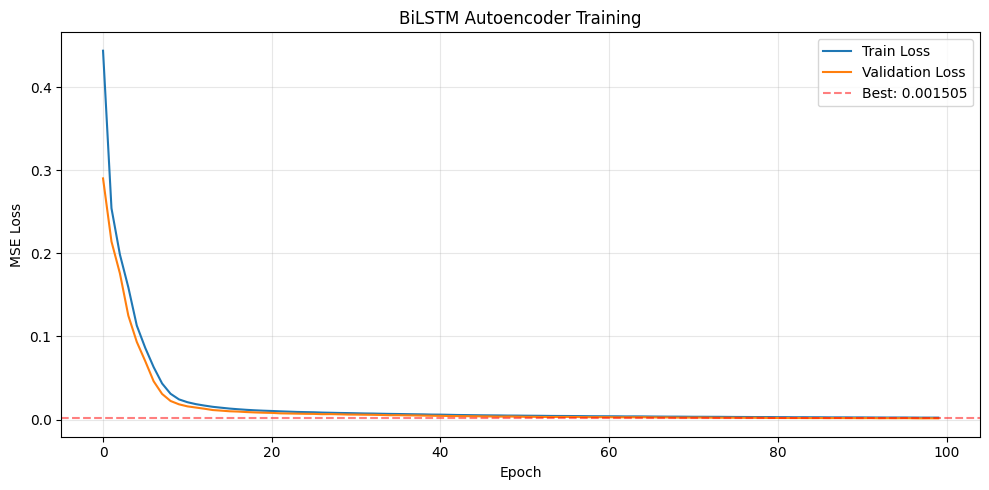

In [22]:
# Cell 8: Training Visualization

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(history['train_loss'], label='Train Loss')
ax.plot(history['val_loss'], label='Validation Loss')
ax.axhline(y=best_val_loss, color='r', linestyle='--', alpha=0.5, label=f'Best: {best_val_loss:.6f}')
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE Loss')
ax.set_title('BiLSTM Autoencoder Training')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(Path(CONFIG['model_dir']) / 'training_loss.png', dpi=150)
plt.show()

In [23]:
# Cell 9: Extract Embeddings

model.load_state_dict(torch.load(best_model_path, map_location=DEVICE, weights_only=True))
model.eval()

all_embeddings = []
all_recon_errors = []

full_loader = DataLoader(TensorDataset(X_tensor, X_tensor), batch_size=CONFIG['batch_size'], shuffle=False)

print("Extracting stress embeddings...")
with torch.no_grad():
    for batch_x, batch_y in full_loader:
        batch_x, batch_y = batch_x.to(DEVICE), batch_y.to(DEVICE)
        reconstruction, embedding = model(batch_x)
        all_embeddings.append(embedding.cpu().numpy())
        recon_error = ((reconstruction - batch_y) ** 2).mean(dim=[1, 2])
        all_recon_errors.append(recon_error.cpu().numpy())

embeddings = np.vstack(all_embeddings)
recon_errors = np.concatenate(all_recon_errors)

print(f"Extracted {embeddings.shape[0]:,} embeddings of dimension {embeddings.shape[1]}")
print(f"Reconstruction error: mean={recon_errors.mean():.6f}, std={recon_errors.std():.6f}")

Extracting stress embeddings...
Extracted 30,000 embeddings of dimension 32
Reconstruction error: mean=0.001303, std=0.003091


Anomaly threshold (95th %ile): 0.004454
Anomalies detected: 1,500 (5.0%)

Anomaly rate - Defaulters: 5.2%, Non-defaulters: 4.9%


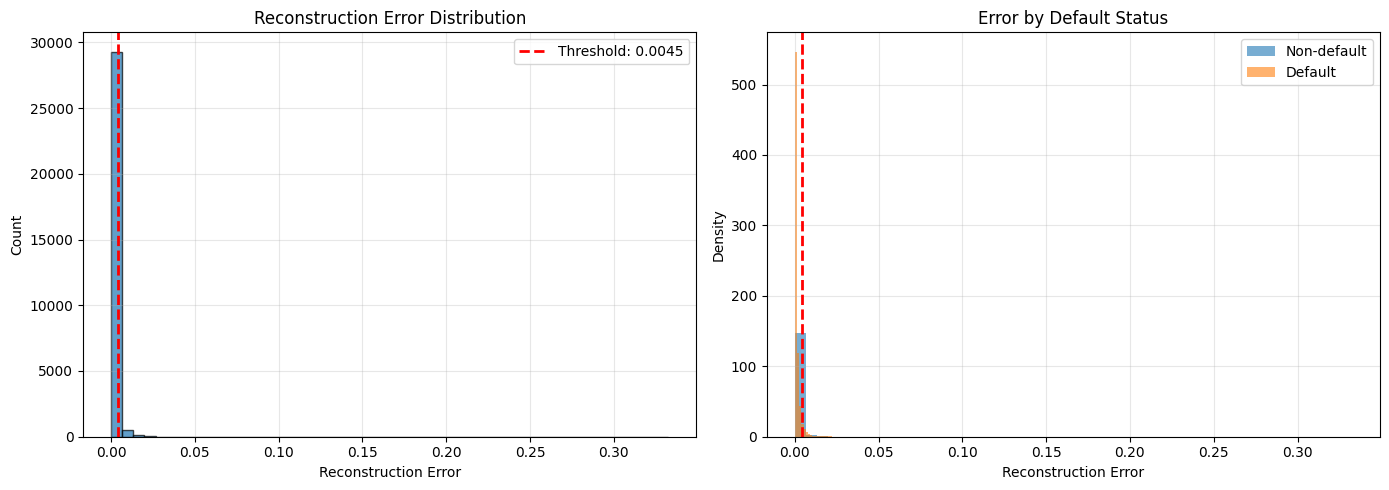

In [24]:
# Cell 10: Anomaly Detection

anomaly_threshold = np.percentile(recon_errors, CONFIG['anomaly_percentile'])
anomaly_flags = (recon_errors > anomaly_threshold).astype(int)

print(f"Anomaly threshold ({CONFIG['anomaly_percentile']}th %ile): {anomaly_threshold:.6f}")
print(f"Anomalies detected: {anomaly_flags.sum():,} ({100*anomaly_flags.mean():.1f}%)")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(recon_errors, bins=50, alpha=0.7, edgecolor='black')
axes[0].axvline(anomaly_threshold, color='r', linestyle='--', linewidth=2, label=f'Threshold: {anomaly_threshold:.4f}')
axes[0].set_xlabel('Reconstruction Error')
axes[0].set_ylabel('Count')
axes[0].set_title('Reconstruction Error Distribution')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

if CONFIG['target_col'] in df.columns:
    defaulters = df[CONFIG['target_col']].values == 1
    axes[1].hist(recon_errors[~defaulters], bins=50, alpha=0.6, label='Non-default', density=True)
    axes[1].hist(recon_errors[defaulters], bins=50, alpha=0.6, label='Default', density=True)
    axes[1].axvline(anomaly_threshold, color='r', linestyle='--', linewidth=2)
    axes[1].set_xlabel('Reconstruction Error')
    axes[1].set_ylabel('Density')
    axes[1].set_title('Error by Default Status')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    print(f"\nAnomaly rate - Defaulters: {100*anomaly_flags[defaulters].mean():.1f}%, Non-defaulters: {100*anomaly_flags[~defaulters].mean():.1f}%")

plt.tight_layout()
plt.savefig(Path(CONFIG['model_dir']) / 'recon_error_dist.png', dpi=150)
plt.show()

DISTRESS TIER VALIDATION
Purpose: Verify that unsupervised embeddings capture distress structure

1. RECONSTRUCTION ERROR BY TIER
--------------------------------------------------
          low (n=10,253): mean=0.001567 ± 0.004161  |  anomaly rate: 5.9%
     moderate (n=12,614): mean=0.000974 ± 0.002129  |  anomaly rate: 3.9%
         high (n=4,500): mean=0.001564 ± 0.002772  |  anomaly rate: 6.2%
       severe (n=2,633): mean=0.001404 ± 0.002379  |  anomaly rate: 4.9%

   ANOVA F-statistic: 84.95,  p-value: 0.00e+00
   → Tiers show statistically significant differences in recon error

   Correlation (recon_error vs distress_encoded): -0.0117

2. PCA VARIANCE EXPLAINED
--------------------------------------------------
   PC1: 35.5%
   PC2: 14.2%
   Top 2 combined: 49.7%

3. t-SNE PROJECTION (n=10,000, computing...)


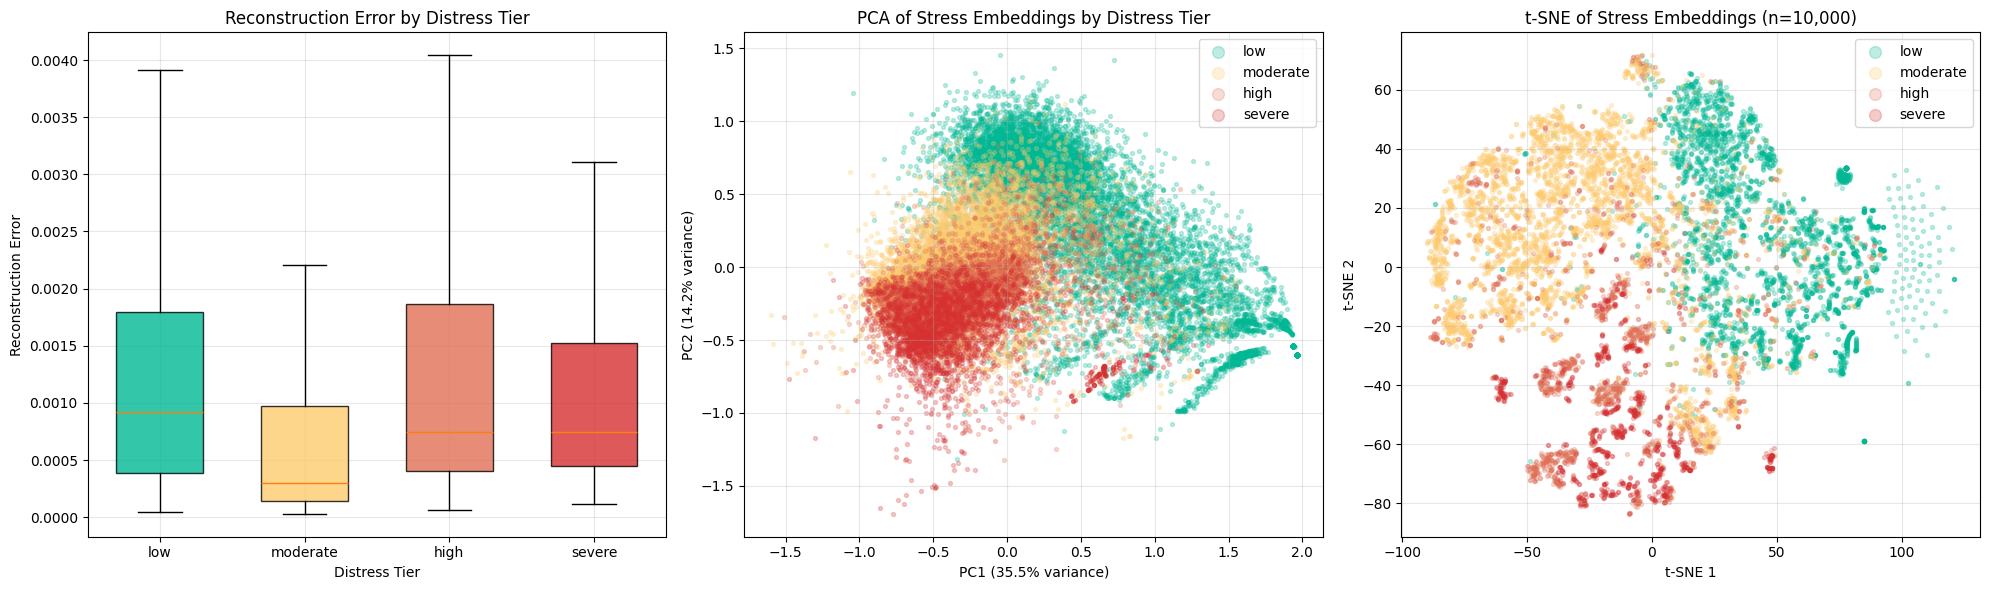

   t-SNE complete.

4. TOP STRESS DIMENSIONS BY |CORRELATION| WITH DISTRESS
--------------------------------------------------
   stress_dim_31: +0.6240
   stress_dim_24: +0.5666
   stress_dim_05: -0.5664
   stress_dim_09: +0.5440
   stress_dim_30: -0.5157
   stress_dim_22: +0.4616
   stress_dim_20: -0.4550
   stress_dim_25: -0.4425
   stress_dim_17: -0.4363
   stress_dim_11: +0.4209

   Strongest |correlation|: 0.6240
   → Some embedding dimensions show meaningful distress correlation

5. ANOMALY FLAG BREAKDOWN BY TIER
--------------------------------------------------
         Tier |  Count | Anomalies |   Rate
   ---------- | ------ | --------- | ------
          low | 10,253 |       604 |   5.9%
     moderate | 12,614 |       489 |   3.9%
         high |  4,500 |       279 |   6.2%
       severe |  2,633 |       128 |   4.9%

VALIDATION COMPLETE


In [28]:
# Cell 10b: Distress Tier Validation — Embedding Quality Assessment
# Validates that the unsupervised BiLSTM embeddings capture distress-relevant
# structure without having seen any labels during training.
#
# This cell is critical for the capstone defense: it proves Branch 2 output
# carries signal that Branch 3 (XGBoost) can exploit for tier classification.

has_distress     = 'distress_level'   in df.columns
has_distress_enc = 'distress_encoded'  in df.columns

if not has_distress:
    print('WARNING: distress_level column not found in dataset.')
    print('This column should exist from Phase A3 merge. Check sbdr_final_dataset.csv.')
else:
    distress_levels = df['distress_level'].values
    tier_order  = ['low', 'moderate', 'high', 'severe']
    tier_colors = {'low': '#00b894', 'moderate': '#fdcb6e', 'high': '#e17055', 'severe': '#d63031'}

    print('DISTRESS TIER VALIDATION')
    print('=' * 60)
    print('Purpose: Verify that unsupervised embeddings capture distress structure')
    print()

    # ── Figure: 3-panel validation plot ──────────────────────────
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))

    # ── Panel 1: Reconstruction Error by Distress Tier ──────────
    tier_errors = [recon_errors[distress_levels == t] for t in tier_order]
    bp = axes[0].boxplot(tier_errors, labels=tier_order, patch_artist=True,
                         showfliers=False, widths=0.6)
    for patch, tier in zip(bp['boxes'], tier_order):
        patch.set_facecolor(tier_colors[tier])
        patch.set_alpha(0.8)
    axes[0].set_xlabel('Distress Tier')
    axes[0].set_ylabel('Reconstruction Error')
    axes[0].set_title('Reconstruction Error by Distress Tier')
    axes[0].grid(True, alpha=0.3)

    print('1. RECONSTRUCTION ERROR BY TIER')
    print('-' * 50)
    for tier in tier_order:
        mask = distress_levels == tier
        mean_e = recon_errors[mask].mean()
        std_e  = recon_errors[mask].std()
        anom_r = anomaly_flags[mask].mean() * 100
        n_tier = mask.sum()
        print(f'   {tier:>10s} (n={n_tier:>5,}): '
              f'mean={mean_e:.6f} ± {std_e:.6f}  |  anomaly rate: {anom_r:.1f}%')

    # ANOVA: are reconstruction errors significantly different across tiers?
    f_stat, p_value = stats.f_oneway(*tier_errors)
    print(f'\n   ANOVA F-statistic: {f_stat:.2f},  p-value: {p_value:.2e}')
    if p_value < 0.05:
        print('   → Tiers show statistically significant differences in recon error')
    else:
        print('   → No significant difference across tiers (expected if distress is subtle)')

    # Correlation: recon_error vs distress_encoded ordinal
    if has_distress_enc:
        r_distress = np.corrcoef(recon_errors, df['distress_encoded'].values)[0, 1]
        print(f'\n   Correlation (recon_error vs distress_encoded): {r_distress:.4f}')

    # ── Panel 2: PCA of Stress Embeddings ──────────────────────
    pca = PCA(n_components=2)
    emb_pca = pca.fit_transform(embeddings)

    for tier in tier_order:
        mask = distress_levels == tier
        axes[1].scatter(emb_pca[mask, 0], emb_pca[mask, 1],
                        c=tier_colors[tier], label=tier, alpha=0.25, s=8)
    axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
    axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
    axes[1].set_title('PCA of Stress Embeddings by Distress Tier')
    axes[1].legend(markerscale=3, loc='upper right')
    axes[1].grid(True, alpha=0.3)

    print(f'\n2. PCA VARIANCE EXPLAINED')
    print('-' * 50)
    print(f'   PC1: {pca.explained_variance_ratio_[0]:.1%}')
    print(f'   PC2: {pca.explained_variance_ratio_[1]:.1%}')
    print(f'   Top 2 combined: {sum(pca.explained_variance_ratio_[:2]):.1%}')

    # ── Panel 3: t-SNE of Stress Embeddings ────────────────────
    # t-SNE is O(n²); subsample to 10K for speed while keeping tier proportions
    n_tsne = min(10_000, len(embeddings))
    tsne_idx = np.random.choice(len(embeddings), n_tsne, replace=False)

    print(f'\n3. t-SNE PROJECTION (n={n_tsne:,}, computing...)')
    tsne = TSNE(n_components=2, perplexity=30, random_state=CONFIG['seed'],
                max_iter=1000, learning_rate='auto', init='pca')
    emb_tsne = tsne.fit_transform(embeddings[tsne_idx])

    for tier in tier_order:
        mask = distress_levels[tsne_idx] == tier
        axes[2].scatter(emb_tsne[mask, 0], emb_tsne[mask, 1],
                        c=tier_colors[tier], label=tier, alpha=0.25, s=8)
    axes[2].set_xlabel('t-SNE 1')
    axes[2].set_ylabel('t-SNE 2')
    axes[2].set_title(f't-SNE of Stress Embeddings (n={n_tsne:,})')
    axes[2].legend(markerscale=3, loc='upper right')
    axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(Path(CONFIG['model_dir']) / 'distress_tier_validation.png', dpi=150)
    plt.show()
    print('   t-SNE complete.')

    # ── Top stress dimensions correlated with distress ──────────
    if has_distress_enc:
        print(f'\n4. TOP STRESS DIMENSIONS BY |CORRELATION| WITH DISTRESS')
        print('-' * 50)
        dim_corrs = []
        for i in range(CONFIG['embed_dim']):
            r = np.corrcoef(embeddings[:, i], df['distress_encoded'].values)[0, 1]
            dim_corrs.append((f'stress_dim_{i:02d}', r))

        dim_corrs.sort(key=lambda x: abs(x[1]), reverse=True)
        for name, r in dim_corrs[:10]:
            print(f'   {name}: {r:+.4f}')

        max_abs_corr = max(abs(r) for _, r in dim_corrs)
        print(f'\n   Strongest |correlation|: {max_abs_corr:.4f}')
        if max_abs_corr > 0.15:
            print('   → Some embedding dimensions show meaningful distress correlation')
        else:
            print('   → Weak individual correlations — stress signal is distributed across dimensions')
            print('     (Expected for unsupervised autoencoder; XGBoost will combine them)')

    # ── Summary table: anomaly flag breakdown ───────────────────
    print(f'\n5. ANOMALY FLAG BREAKDOWN BY TIER')
    print('-' * 50)
    print(f'   {"Tier":>10s} | {"Count":>6s} | {"Anomalies":>9s} | {"Rate":>6s}')
    print(f'   {"-"*10} | {"-"*6} | {"-"*9} | {"-"*6}')
    for tier in tier_order:
        mask = distress_levels == tier
        n_t  = mask.sum()
        n_a  = anomaly_flags[mask].sum()
        rate = anomaly_flags[mask].mean() * 100
        print(f'   {tier:>10s} | {n_t:>6,} | {n_a:>9,} | {rate:>5.1f}%')

    print('\n' + '=' * 60)
    print('VALIDATION COMPLETE')
    print('=' * 60)


In [29]:
# Cell 11: Save Output CSV

stress_cols = [f'stress_dim_{i:02d}' for i in range(CONFIG['embed_dim'])]
embeddings_df = pd.DataFrame(embeddings, columns=stress_cols, index=df.index)
embeddings_df['bilstm_recon_error'] = recon_errors
embeddings_df['bilstm_anomaly_flag'] = anomaly_flags

df_output = pd.concat([df, embeddings_df], axis=1)
df_output.to_csv(CONFIG['output_path'], index=False)

print(f"Output saved to: {CONFIG['output_path']}")
print(f"Total columns: {len(df_output.columns)} (added {len(stress_cols) + 2} new)")
print(f"  - 32 stress dimensions: {stress_cols[0]} to {stress_cols[-1]}")
print(f"  - bilstm_recon_error")
print(f"  - bilstm_anomaly_flag")

Output saved to: ../../../data/processed/06_with_stress_vectors.csv
Total columns: 122 (added 34 new)
  - 32 stress dimensions: stress_dim_00 to stress_dim_31
  - bilstm_recon_error
  - bilstm_anomaly_flag


In [30]:
# Cell 12: Save Manifest

# Save train/val indices so downstream notebooks (FinBERT, XGBoost) use the same split
split_path = Path(CONFIG['model_dir']) / 'train_val_indices.npz'
np.savez(split_path, train_idx=train_idx_np, val_idx=val_idx_np)
print(f'Train/val indices saved to: {split_path}')

manifest = {
    'notebook': '06_bilstm_stress_patterns',
    'output_file': CONFIG['output_path'],
    'model_checkpoint': str(best_model_path),
    'split_indices_file': str(split_path),
    'stress_embedding_cols': stress_cols,
    'metadata_cols': ['bilstm_recon_error', 'bilstm_anomaly_flag'],
    'model_config': {k: CONFIG[k] for k in ['seq_len', 'n_features', 'hidden_size', 'num_layers', 'embed_dim', 'dropout']},
    'input_features': {k: CONFIG[k] for k in ['pay_status_cols', 'bill_amt_cols', 'pay_amt_cols', 'util_ratio_cols', 'pay_ratio_cols']},
    'normalization_params': norm_params,
    'anomaly_detection': {
        'threshold_percentile': CONFIG['anomaly_percentile'],
        'threshold_value': float(anomaly_threshold),
        'n_anomalies': int(anomaly_flags.sum()),
        'anomaly_rate': float(anomaly_flags.mean())
    },
    'training_summary': {
        'best_val_loss': float(best_val_loss),
        'epochs_trained': len(history['train_loss'])
    },
    'split_info': {
        'n_train': int(len(train_idx_np)),
        'n_val': int(len(val_idx_np)),
        'seed': CONFIG['seed']
    }
}

with open(CONFIG['manifest_path'], 'w') as f:
    json.dump(manifest, f, indent=2)

print(f'Manifest saved to: {CONFIG["manifest_path"]}')
print('\n' + '=' * 50)
print('NOTEBOOK 06 COMPLETE')
print('=' * 50)


Train/val indices saved to: ../../../models/bilstm/train_val_indices.npz
Manifest saved to: ../../../models/bilstm/bilstm_manifest.json

NOTEBOOK 06 COMPLETE


In [31]:
# Cell 13: Sanity Check

print("SANITY CHECK")
print("="*50)

df_check = pd.read_csv(CONFIG['output_path'])
print(f"1. Output readable:        OK - Shape {df_check.shape}")
print(f"2. Stress columns present: {'OK' if all(c in df_check.columns for c in stress_cols) else 'FAIL'}")
print(f"3. No NaN in stress cols:  {'OK' if df_check[stress_cols].isna().sum().sum() == 0 else 'FAIL'}")
print(f"4. Anomaly flag binary:    {'OK' if set(df_check['bilstm_anomaly_flag'].unique()) <= {0, 1} else 'FAIL'}")
print(f"5. customer_id present:    {'OK' if 'customer_id' in df_check.columns else 'FAIL — customer_id column missing!'}")

if CONFIG['target_col'] in df_check.columns:
    corr = df_check['bilstm_recon_error'].corr(df_check[CONFIG['target_col']])
    print(f"6. Recon error vs default correlation: {corr:.4f}")

print("\n" + "="*50)
print("Ready for Notebook 07 (XGBoost)!")
print("="*50)


SANITY CHECK
1. Output readable:        OK - Shape (30000, 122)
2. Stress columns present: OK
3. No NaN in stress cols:  OK
4. Anomaly flag binary:    OK
5. customer_id present:    OK
6. Recon error vs default correlation: 0.0085

Ready for Notebook 07 (XGBoost)!
